In [19]:
import numpy as np
performance = np.array([55,60,65,70,75,80,85,90,95,98])
attendance = np.array([70,75,78,80,82,85,88,92,95,98])
experience = np.array([1,2,2,3,4,5,6,7,8,10])

promotion = np.array([0,0,0,0,1,1,1,1,1,1])

In [20]:
import pandas as pd
df = pd.DataFrame({"Performance Score": performance,"Attendance (%)": attendance,
    "Experience (Years)": experience,"Promotion": promotion})
print("===== Employee Dataset =======\n")
print(df)

===== Employee Dataset =======

   Performance Score  Attendance (%)  Experience (Years)  Promotion
0                 55              70                   1          0
1                 60              75                   2          0
2                 65              78                   2          0
3                 70              80                   3          0
4                 75              82                   4          1
5                 80              85                   5          1
6                 85              88                   6          1
7                 90              92                   7          1
8                 95              95                   8          1
9                 98              98                  10          1


In [21]:
from sklearn.model_selection import train_test_split
X = df[["Performance Score", "Attendance (%)", "Experience (Years)"]]
y = df["Promotion"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

fromsklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n---------- Predictions ----------")
print(y_pred)


---------- Predictions ----------
[1 0 1]


In [22]:
new_employee = pd.DataFrame({"Performance Score":[88],"Attendance (%)":[90],
                             "Experience (Years)": [6]})
prediction = model.predict(new_employee)
prediction = model.predict(new_employee)
print("\n========== New Employee Prediction ==========")
if prediction[0] == 1:
    print("Employee is Likely to be Promoted")
else:
    print("Employee is Not Likely to be Promoted")


========== New Employee Prediction ==========
Employee is Likely to be Promoted


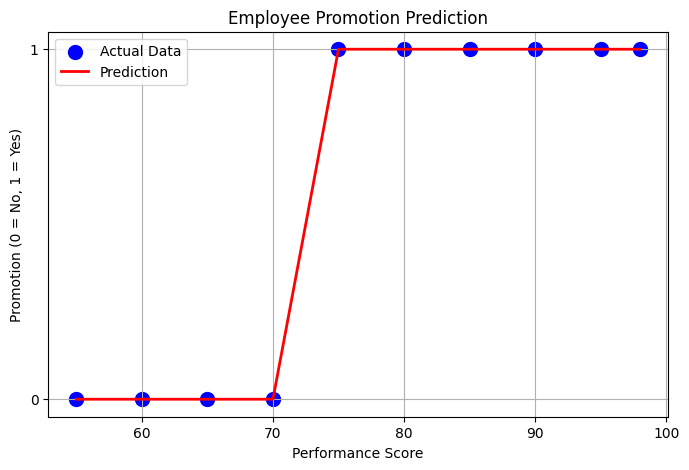

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(performance,promotion,color="blue",s=100,label="Actual Data")
plt.plot(performance,model.predict(X),color="red",linewidth=2,label="Prediction")

plt.title("Employee Promotion Prediction")
plt.xlabel("Performance Score")
plt.ylabel("Promotion (0 = No, 1 = Yes)")
plt.yticks([0,1])
plt.grid(True)
plt.legend()
plt.show()